In [44]:
import pandas
from matplotlib import pyplot as plt

First things first, we read the dataset and print the first 5 rows of the dataset. This gives us a clue of what is contained in the dataset.

In [45]:
df = pandas.read_csv('Suicide_Line_Listing_By_Age_Group_And_Gender_2012-2018.csv', index_col='Record Number')

In [46]:
df.head()

,Year,Age Group (in years),Gender
Record Number,,,
1,2012,≤ 29,FEMALE
2,2012,≤ 29,FEMALE
3,2012,≤ 29,MALE
4,2012,≤ 29,MALE
5,2012,≤ 29,MALE


This dataset is not really that complex. It has just 4 columns. The years the different suicides occured (which we can find in the "Year" Column), the age group of the victims (which we can find in the "Age Group(in years)" column), their gender (which is in the "Gender" column) and the "Record Number" column which we have made our index column.

We noticed that from the dataset, greater than or equal to and less than or equal to are written as ≥ and ≤ respectively. Personally, I find it easier and more conventional to use >= and <= to represent greater than or equal to and less than or equal to respectively.
So, I write a little code to change them.

In [47]:
mask = df['Age Group (in years)'].str.contains('29', case=False, na=False)

df.loc[mask, 'Age Group (in years)'] = '<=29'

In [48]:
mask = df['Age Group (in years)'].str.contains('70', case=False, na=False)
df.loc[mask, 'Age Group (in years)'] = '>=70'

Now, let's get all the years available from the dataset.

In [49]:
years = []
for i in df['Year']:
    if i not in years:
        years.append(i)
years

[2012, 2013, 2014, 2015, 2016, 2017, 2018]


The suicides recorded in this dataset, happened from 2012 to 2018. That's 7 years of suicide events.

In [50]:
deaths = []
for year in years:
    filt = df['Year'] == year
    df_year = df.loc[filt]
    deaths.append(len(df_year))
deaths

[115, 121, 117, 132, 126, 126, 122]

This gives us the number of people that committed suicides each year. For example, 115 in 2012, 121 in 2013, 117 in 2014, and so on.

We can represent this data in a table to enable us get a better view

In [51]:
deaths_by_year_df = pandas.DataFrame(
    {
        'years': years,
        'deaths': deaths
    }
)
deaths_by_year_df

,years,deaths
0,2012,115
1,2013,121
2,2014,117
3,2015,132
4,2016,126
5,2017,126
6,2018,122



The table above helps us see clearly the number of suicides recorded in a particular year.

We can also visualize this information using a bar chart

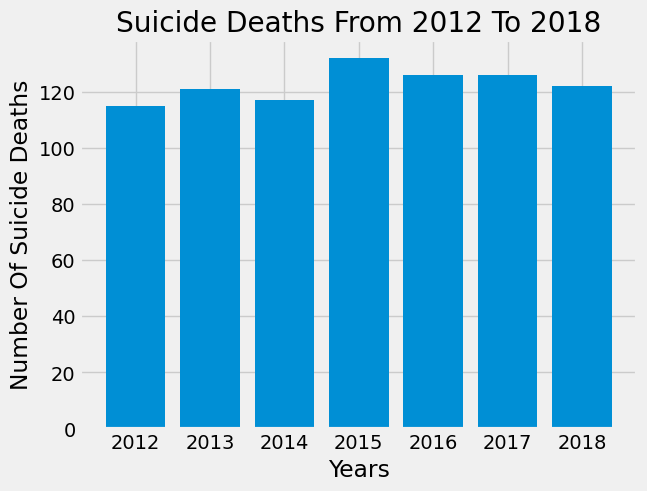

In [52]:
plt.style.use('fivethirtyeight')
plt.bar(years, deaths)
plt.xlabel('Years')
plt.ylabel('Number of Suicide deaths'.title())
plt.title('Suicide deaths from 2012 to 2018'.title())
plt.show()

We can also visualize this using a piechart

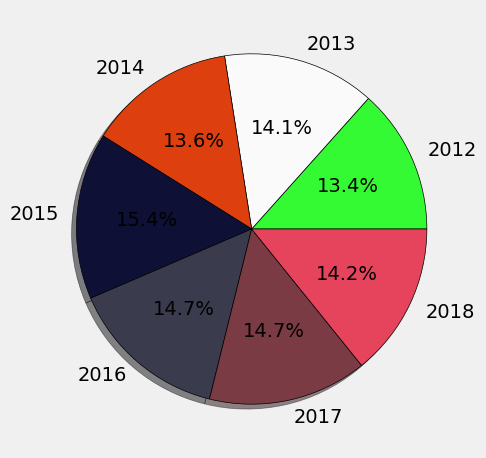

In [53]:
wedgeprops = {'edgecolor':'black'}
colors = ['#34fa33', '#fafafa', '#dd3f0e', '#0f1035', '#3a3b4c', '#7a3b44', '#e5445c']
plt.style.use('fivethirtyeight')
plt.pie(deaths, labels=years, wedgeprops=wedgeprops, colors=colors, autopct='%1.1f%%', shadow=True)
plt.tight_layout()
plt.show()

Now, let us get all the different age groups in the dataset and their respective suicide events.

This is for the different age groups

In [54]:
age_groups = []
for i in df['Age Group (in years)']:
    if i not in age_groups:
        age_groups.append(i)
age_groups

['<=29', '30-49', '50-69', '>=70']

While this is the number of deaths recorded for each age group

In [55]:
age_group_deaths = []
for i in age_groups:
    filt = df['Age Group (in years)'] == i
    age_deaths = df.loc[filt]
    age_group_deaths.append(len(age_deaths))
age_group_deaths

[230, 328, 236, 65]

We can combine the two lists into a single dataframe

In [56]:
age_group_death_df = pandas.DataFrame(
    {
        'AGE GROUP': age_groups,
        'DEATHS': age_group_deaths
    }
)
age_group_death_df

,AGE GROUP,DEATHS
0,<=29,230
1,30-49,328
2,50-69,236
3,>=70,65


We can represent this data in a bar chart

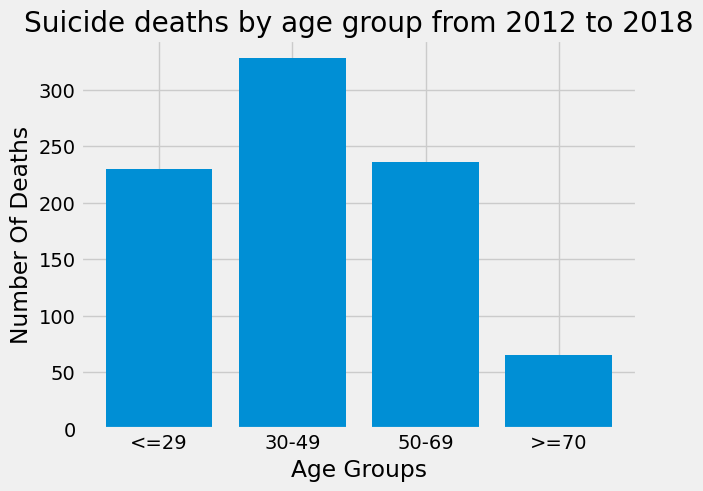

In [57]:
plt.bar(age_groups, age_group_deaths)
plt.title('Suicide deaths by age group from 2012 to 2018')
plt.xlabel('Age Groups')
plt.ylabel('Number Of Deaths')
plt.show()

Or in a pie chart

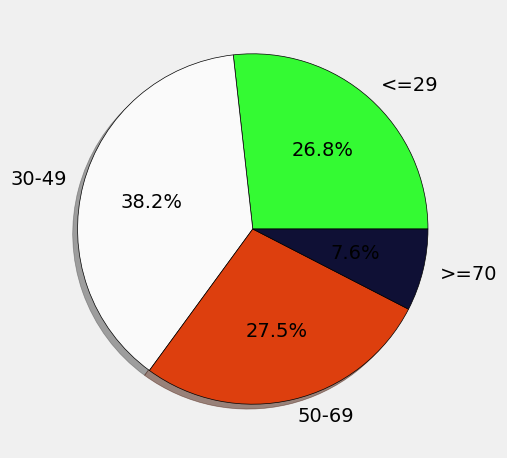

In [58]:
wedgeprops = {'edgecolor':'black'}
colors = ['#34fa33', '#fafafa', '#dd3f0e', '#0f1035', '#3a3b4c', '#7a3b44', '#e5445c']
plt.style.use('fivethirtyeight')
plt.pie(age_group_deaths, labels=age_groups, wedgeprops=wedgeprops, colors=colors, autopct='%1.1f%%', shadow=True)
plt.tight_layout()
plt.show()

From the charts above, we can see that people within the age range of 30-49 has a higher chance of committing suicide than their counterparts from different ages

Now, one may ask
Between the males and females, which gender commits suicides the most?

In [59]:
genders = []
for i in df['Gender']:
    if i not in genders:
        genders.append(i)
genders

['FEMALE', 'MALE']

In [60]:
gender_deaths = {}
for gender in genders:
    filt = df['Gender'] == gender
    gender_deaths_df = df.loc[filt]
    gender_deaths[f'{gender}'] = len(gender_deaths_df)
gender_deaths

{'FEMALE': 215, 'MALE': 644}

In [61]:
suicide_percent = {}
for gender in genders:
    suicide_percent[f'{gender}_percent_suicide'.lower()] = round(((gender_deaths[f'{gender}']/len(df) * 100)), 1)
suicide_percent

{'female_percent_suicide': 25.0, 'male_percent_suicide': 75.0}

From the dataset, there was a number of 215 suicide cases recorded for the female and 644 suicide suicides cases recorded for the females. Which means that about 25% of the recorded suicide cases were female while 75% of the recorded suicide cases were males.
This implies that for every one female dying as a result of suicide, 3 men are dying as a result of suicide
We can visualize this data on a bar chart and on a pie chart

On a bar chart,

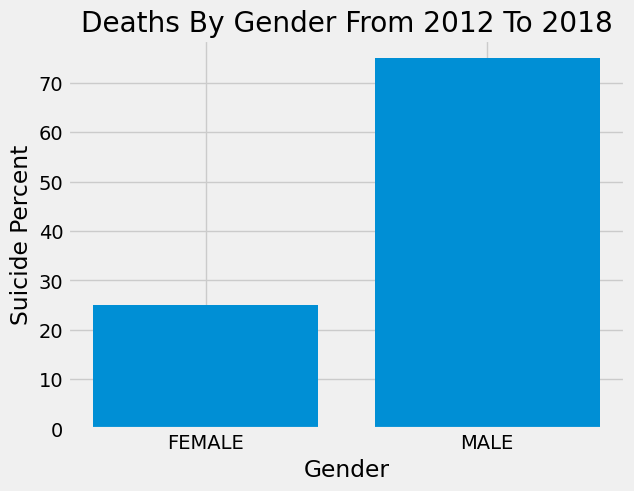

In [62]:

plt.bar(genders, [i for i in suicide_percent.values()])
plt.title('Deaths by gender from 2012 to 2018'.title())
plt.xlabel('Gender')
plt.ylabel('Suicide Percent')
plt.show()

And on a pie chart,

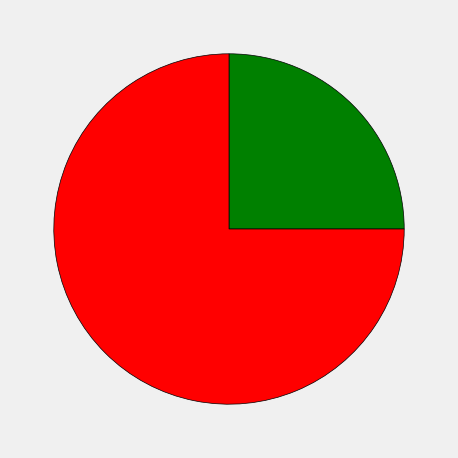

In [63]:
wedgeprops = {'edgecolor': 'black'}
colors = ['green', 'red']
plt.pie([i for i in suicide_percent.values()], colors=colors, wedgeprops=wedgeprops)
plt.style.use('fivethirtyeight')
plt.tight_layout()
plt.show()


Right now, we want to get the genders at different age groups and compare the suicide cases between them.

In [64]:
def get_by_gender_and_age_group(gender, age_group):
    gender_df = df.loc[df['Gender'] == gender]
    gender_age_group_df = gender_df.loc[df['Age Group (in years)'] == age_group]
    return gender_age_group_df

In [65]:
age_groups = []
for age in df['Age Group (in years)']:
    if age not in age_groups:
        age_groups.append(age)

In [66]:
age_group_gender = []
for gender in genders:
    for age_group in age_groups:
        age_group_gender.append((gender, age_group))
age_group_gender

[('FEMALE', '<=29'),
 ('FEMALE', '30-49'),
 ('FEMALE', '50-69'),
 ('FEMALE', '>=70'),
 ('MALE', '<=29'),
 ('MALE', '30-49'),
 ('MALE', '50-69'),
 ('MALE', '>=70')]

We have gotten the different genders and the different age groups between them.
Now, we want to get all the suicide cases

In [67]:
age_group_by_gender_deaths = [len(get_by_gender_and_age_group(gender=i[0], age_group=i[1])) for i in age_group_gender]

In [68]:
age_group_by_gender_deaths

[52, 88, 66, 9, 178, 240, 170, 56]

We can visualize this using a bar chart

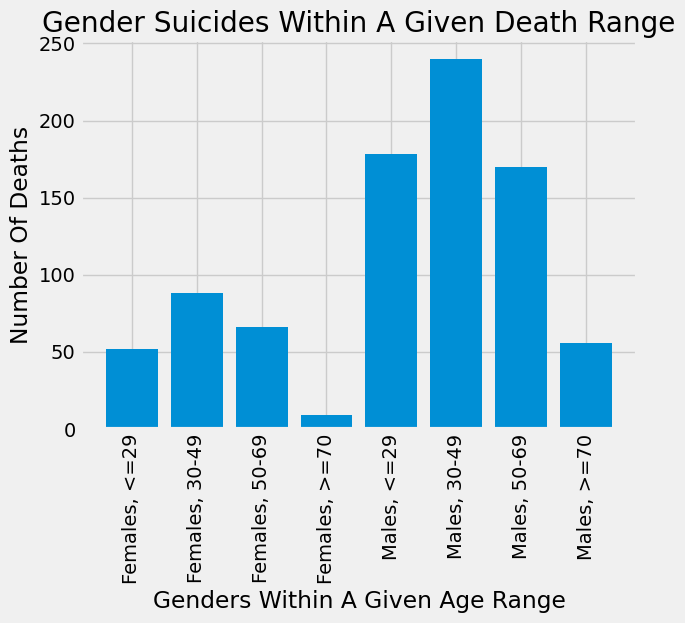

In [69]:
x_axis = [f'{i[0]}s, {i[1]}'.capitalize() for i in age_group_gender]
y_axis = age_group_by_gender_deaths
plt.style.use('fivethirtyeight')
plt.bar(x_axis, y_axis)
plt.xlabel('Genders within a given age range'.title())
plt.ylabel('Number of deaths'.title())
plt.title('Gender suicides within a given death range'.title())
plt.xticks(rotation=90)
plt.show()